<a href="https://colab.research.google.com/github/AceRb6/Modelos_Econometricos/blob/main/PME05_Validaci%C3%B3n_de_supuestos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("elanderos/official-crime-stats-mexico-2015-2023")

print("Path to dataset files:", path)

100%|██████████| 1.88M/1.88M [00:00<00:00, 121MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/elanderos/official-crime-stats-mexico-2015-2023/versions/2


In [ ]:
import os

# Assuming there's only one CSV file in the directory, or we want the first one found.
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]

csv_file_path = os.path.join(path, csv_files[0])
df = pd.read_csv(csv_file_path)
df.head()

,year,entity_code,entity,affected_legal_good,type_of_crime,subtype_of_crime,modality,month,count
0,2015,1,Aguascalientes,Life and bodily integrity,Homicide,Intentional Homicide,With firearm,January,3
1,2015,1,Aguascalientes,Life and bodily integrity,Homicide,Intentional Homicide,With sharp weapon,January,1
2,2015,1,Aguascalientes,Life and bodily integrity,Homicide,Intentional Homicide,With another element,January,0
3,2015,1,Aguascalientes,Life and bodily integrity,Homicide,Intentional Homicide,Not specified,January,2
4,2015,1,Aguascalientes,Life and bodily integrity,Homicide,Manslaughter,With firearm,January,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 332416 entries, 0 to 332415
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   year                 332416 non-null  int64 
 1   entity_code          332416 non-null  int64 
 2   entity               332416 non-null  object
 3   affected_legal_good  332416 non-null  object
 4   type_of_crime        332416 non-null  object
 5   subtype_of_crime     332416 non-null  object
 6   modality             332416 non-null  object
 7   month                332416 non-null  object
 8   count                332416 non-null  int64 
dtypes: int64(3), object(6)
memory usage: 22.8+ MB


In [ ]:
df.describe()

,year,entity_code,count
count,332416.000000,332416.000000,332416.000000
mean,2018.924528,16.500000,52.012960
std,2.546545,9.233107,202.115018
min,2015.000000,1.000000,0.000000
25%,2017.000000,8.750000,0.000000
50%,2019.000000,16.500000,2.000000
75%,2021.000000,24.250000,26.000000
max,2023.000000,32.000000,8421.000000


In [ ]:
# Exploración de categorías reales en el dataset mexicano
print("Tipos de delito (type_of_crime):")
print(df['type_of_crime'].unique())

print("\nSubtipos de delito (subtype_of_crime):")
print(df['subtype_of_crime'].unique())

print("\nBienes jurídicos afectados:")
print(df['affected_legal_good'].unique())

# Frecuencia para priorizar categorías relevantes
print("\nFrecuencia de subtipos de delito:")
print(df['subtype_of_crime'].value_counts().head(20))

Tipos de delito (type_of_crime):
['Homicide' 'Injuries' 'Feminicide' 'Abortion'
 'Other crimes against life and bodily integrity' 'Kidnapping'
 'Child trafficking' 'Abduction' 'Other crimes against personal freedom'
 'Sexual abuse' 'Sexual harassment' 'Simple rape' 'Aggravated rape'
 'Incest' 'Other crimes against sexual freedom and security' 'Robbery'
 'Fraud' 'Embezzlement' 'Extortion' 'Property damage' 'Dispossession'
 'Other crimes against heritage or property' 'Domestic violence'
 'Gender-based violence in all its forms other than domestic violence'
 'Non-compliance with family support obligations'
 'Other crimes against the family' 'Corruption of minors'
 'Human trafficking' 'Other crimes against society'
 'Drug trafficking (small-scale)' 'Threats' 'Burglary' 'Prisoner escape'
 'Forgery' 'Counterfeiting' 'Environmental crimes'
 'Crimes committed by public officials' 'Electoral crimes'
 'Other common law crimes']

Subtipos de delito (subtype_of_crime):
['Intentional Homicide' 'Man

In [ ]:
# Mapeo de variables objetivo
mapeo = {
    'Murder': ['Intentional Homicide', 'Feminicide'],  # Homicidio doloso como variable dependiente
    'Theft': [
        'Motor Vehicle Theft', 'Home Burglary', 'Street Robbery',
        'Public Space Robbery', 'Business Robbery', 'Bank Institution Robbery',
        'Carrier Theft', 'Auto Parts Theft', 'Cattle Theft',
        'Machinery Theft', 'Other Thefts', 'Housebreaking'
    ],
    'Kidnapping': ['Kidnapping', 'Abduction', 'Child Trafficking'],
    'Assault_women': [
        'Feminicide', 'Family Violence',
        'Gender Violence in all its forms other than family violence',
        'Sexual Abuse', 'Sexual Harassment', 'Sexual Bullying'
    ]
}

# Validar que todas las categorías existen en el dataset
for categoria, subtipos in mapeo.items():
    existentes = [s for s in subtipos if s in df['subtype_of_crime'].values]
    if not existentes:
        print(f"⚠ {categoria}: sin coincidencias en subtype_of_crime")
    mapeo[categoria] = existentes  # Actualizar con solo los existentes

# Agregar conteos por año (nivel nacional) para serie temporal
work_df = df[df['subtype_of_crime'].isin(
    [s for lista in mapeo.values() for s in lista]
)].copy()

# Crear variable agrupada
work_df['crime_group'] = work_df['subtype_of_crime'].apply(
    lambda x: next((k for k, v in mapeo.items() if x in v), None)
)

# Pivotear: año × grupo de delito
pivot_df = work_df.pivot_table(
    index=['year', 'entity'],
    columns='crime_group',
    values='count',
    aggfunc='sum',
    fill_value=0
).reset_index()

# Base nacional (agregar por año)
national_df = pivot_df.groupby('year').sum(numeric_only=True).reset_index()

# Renombrar para alineación con práctica
national_df = national_df.rename(columns={
    'Murder': 'Murder',
    'Theft': 'Theft',
    'Kidnapping': 'Kidnapping',
    'Assault_women': 'Assault_women'
})

print(national_df.head())

crime_group  year  Assault_women  Kidnapping  Murder   Theft
0            2015         142942        1429   16532  633923
1            2016         173528        1585   20756  680649
2            2017         190372        1529   25777  781337
3            2018         205303        1489   29993  786142
4            2019         243111        1475   30442  743150


Observaciones críticas:
* Feminicide aparece en dos grupos (Murder y Assault_women). Decida si duplicar o asignar exclusivamente a una categoría según el objetivo analítico.
* El dataset incluye entity (entidad federativa). Si requiere panel, mantenga la estructura year × entity; si requiere serie temporal, use national_df.
* verificar rango temporal: national_df['year'].min() a national_df['year'].max() para confirmar cobertura 2015-2023.

In [ ]:
# Verificar rango temporal y estructura
print(f"Rango temporal: {df['year'].min()} - {df['year'].max()}")
print(f"Entidades: {df['entity'].nunique()}")
print(f"Total observaciones originales: {len(df)}")

Rango temporal: 2015 - 2023
Entidades: 32
Total observaciones originales: 332416


In [ ]:
# Construir base de trabajo con mapeo validado
mapeo = {
    'Murder': ['Intentional Homicide', 'Feminicide'],
    'Theft': [
        'Motor Vehicle Theft', 'Home Burglary', 'Street Robbery',
        'Public Space Robbery', 'Business Robbery', 'Bank Institution Robbery',
        'Carrier Theft', 'Auto Parts Theft', 'Cattle Theft',
        'Machinery Theft', 'Other Thefts', 'Housebreaking'
    ],
    'Kidnapping': ['Kidnapping', 'Abduction', 'Child Trafficking'],
    'Assault_women': [
        'Family Violence',
        'Gender Violence in all its forms other than family violence',
        'Sexual Abuse', 'Sexual Harassment', 'Sexual Bullying'
    ]
}

# Filtrar y agregar
work_df = df[df['subtype_of_crime'].isin(
    [s for lista in mapeo.values() for s in lista]
)].copy()

work_df['crime_group'] = work_df['subtype_of_crime'].apply(
    lambda x: next((k for k, v in mapeo.items() if x in v), None)
)

# Pivotear por año y entidad (panel)
pivot_df = work_df.pivot_table(
    index=['year', 'entity'],
    columns='crime_group',
    values='count',
    aggfunc='sum',
    fill_value=0
).reset_index()

# Base nacional para serie temporal
national_df = pivot_df.groupby('year').sum(numeric_only=True).reset_index()
national_df = national_df.rename(columns={col: col for col in mapeo.keys()})

print(f"\nBase final: {len(national_df)} observaciones (años)")
print(national_df.head())


Base final: 9 observaciones (años)
crime_group  year  Assault_women  Kidnapping  Murder   Theft
0            2015         142942        1429   16532  633923
1            2016         173528        1585   20756  680649
2            2017         190372        1529   25777  781337
3            2018         205303        1489   29993  786142
4            2019         243111        1475   30442  743150


Observaciones: 9
Valores faltantes:
crime_group
year             0
Assault_women    0
Kidnapping       0
Murder           0
Theft            0
dtype: int64
crime_group        Murder          Theft   Kidnapping  Assault_women
count            9.000000       9.000000     9.000000       9.000000
mean         25748.333333  653045.555556  1148.666667  235884.777778
std           4939.963841  103440.181553   442.998025   61849.574657
min          16532.000000  477434.000000   448.000000  142942.000000
25%          21948.000000  591924.000000   783.000000  190372.000000
50%          27239.000000  633923.000000  1429.000000  243111.000000
75%          29786.000000  743150.000000  1489.000000  294780.000000
max          30442.000000  786142.000000  1585.000000  323183.000000


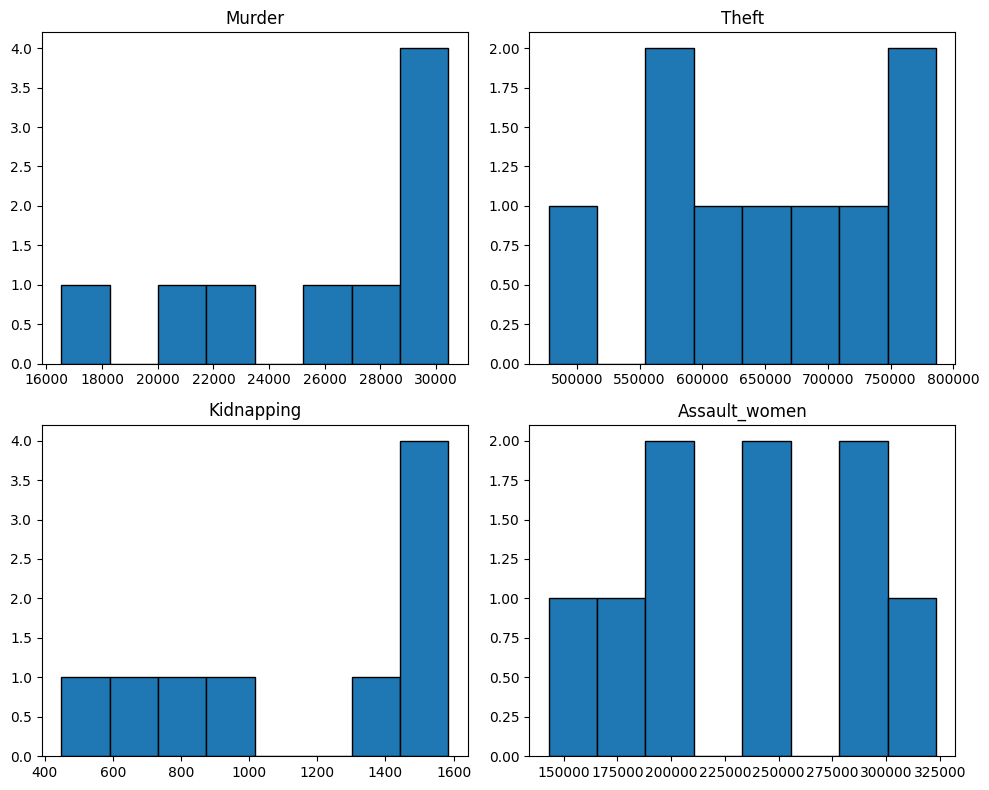

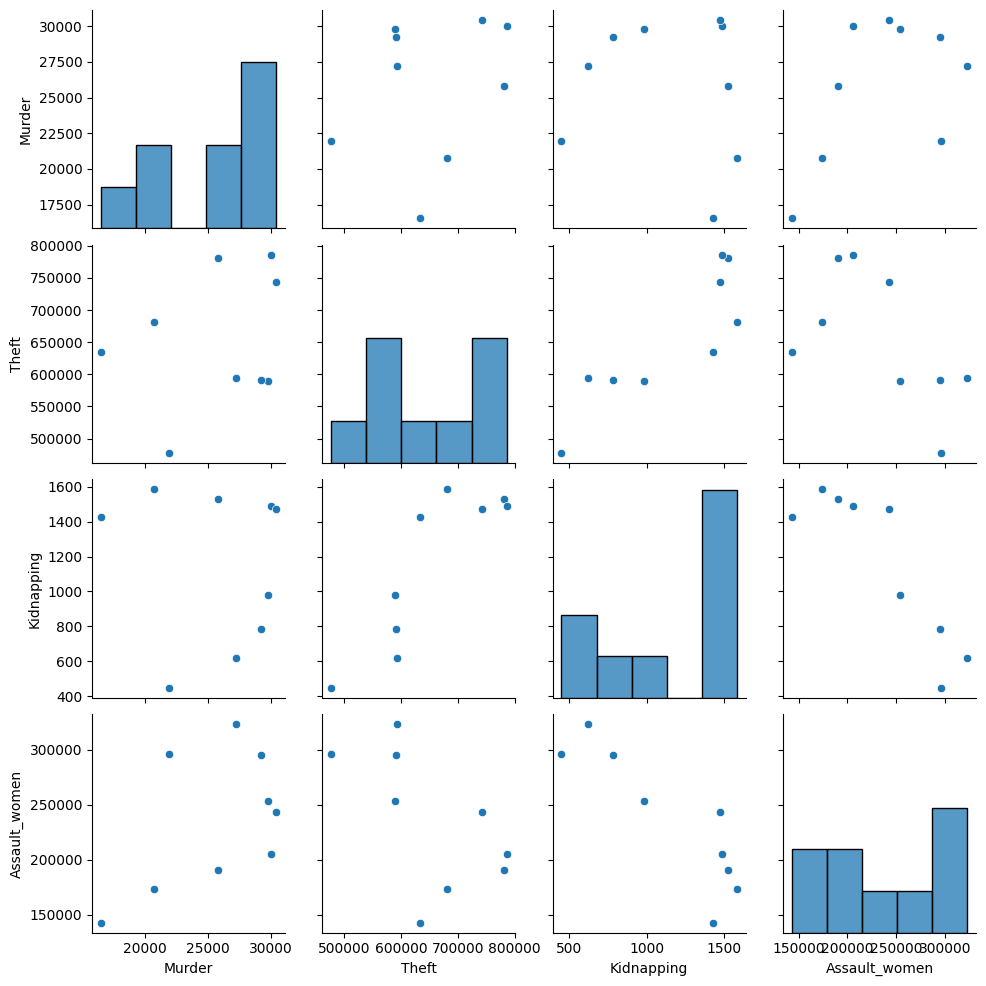

In [ ]:
# Carga y preguntas básicas
print(f"Observaciones: {len(national_df)}")
print(f"Valores faltantes:\n{national_df.isnull().sum()}")

# EDA
import matplotlib.pyplot as plt
import seaborn as sns

# Estadísticas descriptivas
print(national_df[mapeo.keys()].describe())

# Histogramas y dispersión
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for i, col in enumerate(mapeo.keys()):
    ax = axes[i//2, i%2]
    ax.hist(national_df[col], bins=8, edgecolor='black')
    ax.set_title(col)
plt.tight_layout()

# Matriz de dispersión
sns.pairplot(national_df[list(mapeo.keys())])
plt.show()

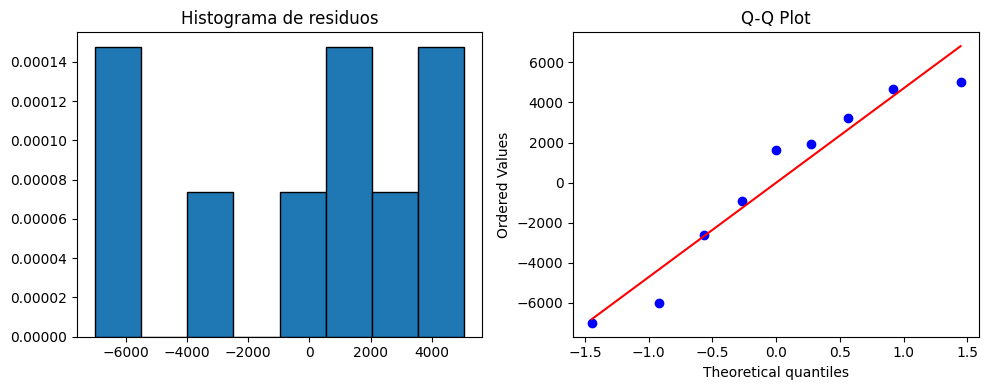


Jarque-Bera: stat=0.830, p-value=0.660
Kolmogorov-Smirnov: stat=0.199, p-value=0.805


In [ ]:
# Normalidad
from scipy import stats
import scipy.stats as st
import statsmodels.api as sm

X = sm.add_constant(national_df['year']) # Add a constant for the intercept
y = national_df['Murder'] # Dependent variable

# Fit the OLS model
model = sm.OLS(y, X)
results = model.fit()

# Get the residuals
resids = results.resid

# Histograma + Q-Q
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(resids, bins=8, edgecolor='black', density=True)
axes[0].set_title('Histograma de residuos')

st.probplot(resids, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot')
plt.tight_layout()
plt.show()

# Pruebas estadísticas
jb_stat, jb_pval = stats.jarque_bera(resids)
# For kstest, the distribution needs to be specified with its parameters (mean, std)
ks_stat, ks_pval = stats.kstest(resids, 'norm', args=(resids.mean(), resids.std()))

print(f"\nJarque-Bera: stat={jb_stat:.3f}, p-value={jb_pval:.3f}")
print(f"Kolmogorov-Smirnov: stat={ks_stat:.3f}, p-value={ks_pval:.3f}")
# H0: normalidad. Si p-value < 0.05, rechazar H0 → no normal


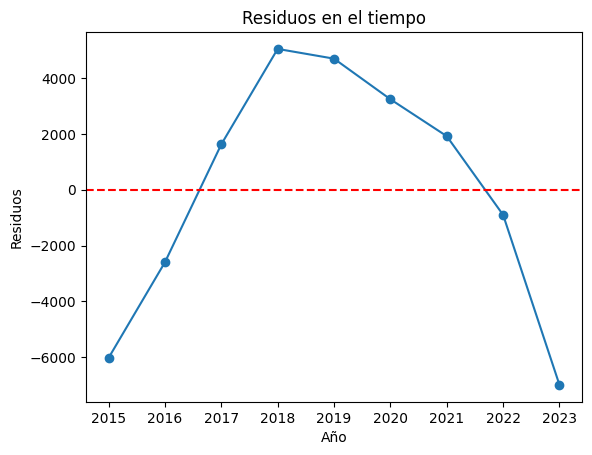


Durbin-Watson: 0.575


In [ ]:
# Autocorrelación (datos ya ordenados por año)
# Gráfico de residuos en el tiempo
plt.plot(national_df['year'], resids, marker='o')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Año')
plt.ylabel('Residuos')
plt.title('Residuos en el tiempo')
plt.show()

# Durbin-Watson
dw_stat = sm.stats.durbin_watson(resids)
print(f"\nDurbin-Watson: {dw_stat:.3f}")
# Regla: DW ≈ 2 → sin autocorrelación; DW < 1.5 o > 2.5 → posible autocorrelación

Matriz de correlación entre variables explicativas:
crime_group       Theft  Kidnapping  Assault_women
crime_group                                       
Theft          1.000000    0.866732      -0.579849
Kidnapping     0.866732    1.000000      -0.873887
Assault_women -0.579849   -0.873887       1.000000

Factor de Inflación de Varianza (VIF):
          VIF       variable
0  392.185480          Theft
1  156.725233     Kidnapping
2   70.613709  Assault_women


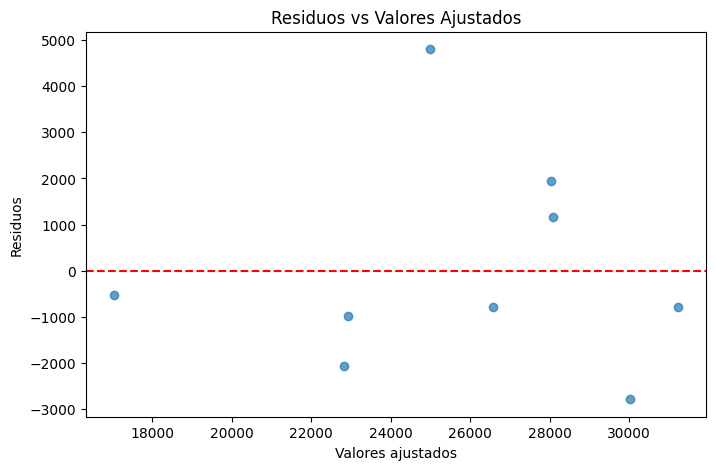


Prueba Breusch-Pagan:
Estadístico: 0.968, p-value: 0.809
H0: Homocedasticidad | Si p-value < 0.05 → Heterocedasticidad


In [ ]:
# Multicolinealidad
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import matplotlib.pyplot as plt

X = national_df[['Theft', 'Kidnapping', 'Assault_women']]
X_const = sm.add_constant(X)
y = national_df['Murder']

# Matriz de correlación
print("Matriz de correlación entre variables explicativas:")
print(X.corr())

# VIF
vif = pd.DataFrame()
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif["variable"] = X.columns
print("\nFactor de Inflación de Varianza (VIF):")
print(vif)

# 5.4 Heterocedasticidad
model = sm.OLS(y, X_const).fit()
resids = model.resid
fitted = model.fittedvalues

# Gráfico residuos vs ajustados
plt.figure(figsize=(8, 5))
plt.scatter(fitted, resids, alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Valores ajustados')
plt.ylabel('Residuos')
plt.title('Residuos vs Valores Ajustados')
plt.show()

# Prueba Breusch-Pagan
bp_stat, bp_pval, _, _ = sm.stats.diagnostic.het_breuschpagan(resids, X_const)
print(f"\nPrueba Breusch-Pagan:")
print(f"Estadístico: {bp_stat:.3f}, p-value: {bp_pval:.3f}")
print("H0: Homocedasticidad | Si p-value < 0.05 → Heterocedasticidad")

In [ ]:
# Autocorrelación
dw_stat = sm.stats.durbin_watson(resids)
print(f"\nEstadístico Durbin-Watson: {dw_stat:.3f}")

# Mostrar resumen del modelo
print("RESUMEN DEL MODELO ORIGINAL")
print(model.summary())


Estadístico Durbin-Watson: 1.927
RESUMEN DEL MODELO ORIGINAL
                            OLS Regression Results                            
Dep. Variable:                 Murder   R-squared:                       0.781
Model:                            OLS   Adj. R-squared:                  0.650
Method:                 Least Squares   F-statistic:                     5.960
Date:                Sat, 18 Apr 2026   Prob (F-statistic):             0.0418
Time:                        07:44:16   Log-Likelihood:                -81.943
No. Observations:                   9   AIC:                             171.9
Df Residuals:                       5   BIC:                             172.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------

Multicolinealidad severa impide interpretar efectos individuales. R²=0.781 pero ninguna variable es significativa (p>0.05).

MODELO CON VARIABLES REDUCIDAS
                            OLS Regression Results                            
Dep. Variable:                 Murder   R-squared:                       0.760
Model:                            OLS   Adj. R-squared:                  0.680
Method:                 Least Squares   F-statistic:                     9.517
Date:                Sat, 18 Apr 2026   Prob (F-statistic):             0.0138
Time:                        07:46:19   Log-Likelihood:                -82.358
No. Observations:                   9   AIC:                             170.7
Df Residuals:                       6   BIC:                             171.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const         -

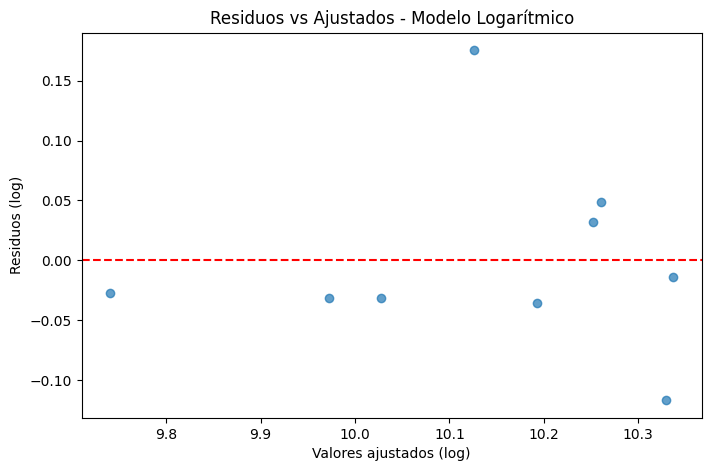


INTERPRETACIÓN DE COEFICIENTES (elasticidades):
Theft: Un aumento de 1% en Theft se asocia con un aumento de 1.0585% en Murder
Assault_women: Un aumento de 1% en Assault_women se asocia con un aumento de 0.8071% en Murder


In [ ]:
# MEDIDAS CORRECTIVAS
import numpy as np
import statsmodels.api as sm
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt

# Corrección 1: Eliminar variables altamente correlacionadas
# Kidnapping correlacionada con Theft (0.87) y Assault_women (-0.87)
X_reducido = national_df[['Theft', 'Assault_women']]
X_reducido_const = sm.add_constant(X_reducido)
y = national_df['Murder']

model_reducido = sm.OLS(y, X_reducido_const).fit()
print("MODELO CON VARIABLES REDUCIDAS")
print(model_reducido.summary())

# VIF del modelo reducido
vif_reducido = pd.DataFrame()
vif_reducido["VIF"] = [variance_inflation_factor(X_reducido.values, i)
                        for i in range(X_reducido.shape[1])]
vif_reducido["variable"] = X_reducido.columns
print("\nVIF post-corrección:")
print(vif_reducido)

# Corrección 2: Transformación logarítmica (estabiliza escala y reduce multicolinealidad)
national_df_log = national_df.copy()
for col in ['Murder', 'Theft', 'Kidnapping', 'Assault_women']:
    national_df_log[col] = np.log1p(national_df[col])

X_log = national_df_log[['Theft', 'Assault_women']]  # Sin Kidnapping
X_log_const = sm.add_constant(X_log)
y_log = national_df_log['Murder']

model_log = sm.OLS(y_log, X_log_const).fit()
print("\n" + "="*60)
print("MODELO LOGARÍTMICO (elasticidades)")
print("="*60)
print(model_log.summary())

# Validación post-corrección
resids_log = model_log.resid
fitted_log = model_log.fittedvalues

# Gráfico residuos
plt.figure(figsize=(8, 5))
plt.scatter(fitted_log, resids_log, alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Valores ajustados (log)')
plt.ylabel('Residuos (log)')
plt.title('Residuos vs Ajustados - Modelo Logarítmico')
plt.show()

# Interpretación de coeficientes log-log
print("\nINTERPRETACIÓN DE COEFICIENTES (elasticidades):")
for var in ['Theft', 'Assault_women']:
    coef = model_log.params[var]
    print(f"{var}: Un aumento de 1% en {var} se asocia con un aumento de {coef:.4f}% en Murder")